In [2]:
import pandas as pd

# File spam.csv thường có encoding latin-1, không phải utf-8
df = pd.read_csv("../data/spam.csv", encoding="latin-1")

# File gốc thường có 5 cột, 3 cột cuối rác — xóa đi, đổi tên cột
df = df[["v1", "v2"]]
df.columns = ["label", "text"]

print(df.shape)
print(df["label"].value_counts())
df.head()

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


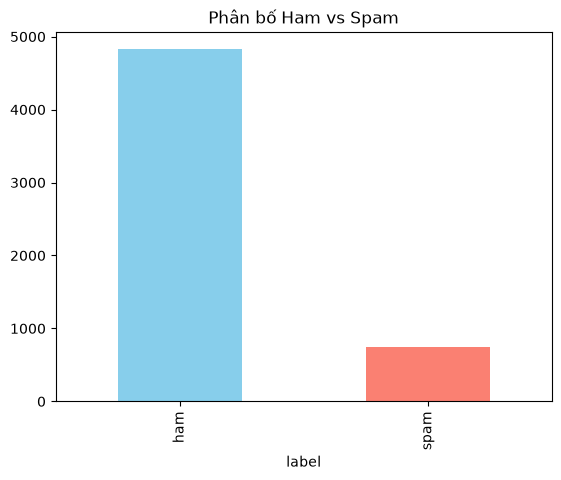

In [3]:
import matplotlib.pyplot as plt

print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True) * 100)  # tỉ lệ %

df["label"].value_counts().plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Phân bố Ham vs Spam")
plt.show()

In [4]:
print(df.isnull().sum())
print("Số dòng trùng lặp:", df.duplicated().sum())

# Nên xóa duplicate để tránh model học lệch
df = df.drop_duplicates()
print("Sau khi xóa duplicate:", df.shape)

label    0
text     0
dtype: int64
Số dòng trùng lặp: 403
Sau khi xóa duplicate: (5169, 2)


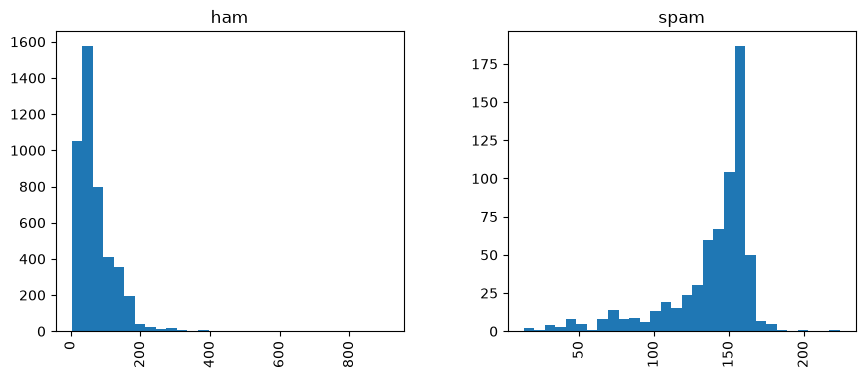

In [5]:
df["text_length"] = df["text"].apply(len)

df.groupby("label")["text_length"].describe()

df.hist(column="text_length", by="label", bins=30, figsize=(10,4))
plt.show()

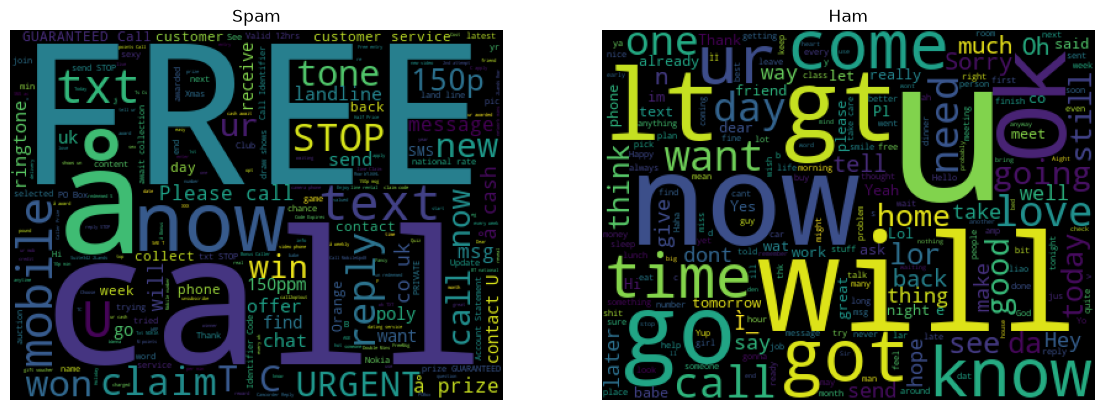

In [6]:

from wordcloud import WordCloud

spam_text = " ".join(df[df["label"]=="spam"]["text"])
ham_text = " ".join(df[df["label"]=="ham"]["text"])

fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].imshow(WordCloud(width=400, height=300).generate(spam_text))
axes[0].set_title("Spam")
axes[0].axis("off")
axes[1].imshow(WordCloud(width=400, height=300).generate(ham_text))
axes[1].set_title("Ham")
axes[1].axis("off")
plt.show()

In [7]:
import sys
sys.path.append("../src")
from preprocessing import preprocess

sample = "WINNER!! You have been selected to receive a £900 prize reward! Call 09061234567 now! www.claimnow.com"
print(preprocess(sample))

winner select receiv prize reward call


[nltk_data] Downloading package stopwords to C:\Users\NGUYEN
[nltk_data]     CONG\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\NGUYEN
[nltk_data]     CONG\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\NGUYEN
[nltk_data]     CONG\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [8]:
df["clean_text"] = df["text"].apply(preprocess)
df[["text", "clean_text"]].sample(5)

,text,clean_text
593,You still at grand prix?,still grand prix
3645,Carlos says we can pick up from him later so y...,carlo say pick later yeah set
676,Maybe?! Say hi to and find out if got his ca...,mayb say hi find got card great escap wetherspoon
570,Yar lor wait 4 my mum 2 finish sch then have l...,yar lor wait mum finish sch lunch lor whole mo...
4264,&lt;DECIMAL&gt; m but its not a common car he...,ltdecimalgt common car better buy china asia f...


In [9]:
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

In [10]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]        # văn bản đã làm sạch
y = df["label_num"]         # nhãn 0/1

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # giữ nguyên tỉ lệ spam/ham giữa train và test
    random_state=42       # cố định để tái lập kết quả
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Tỉ lệ spam trong Train:", y_train.mean())
print("Tỉ lệ spam trong Test:", y_test.mean())

Train: (4135,) | Test: (1034,)
Tỉ lệ spam trong Train: 0.12623941958887544
Tỉ lệ spam trong Test: 0.12669245647969052


In [11]:
import joblib

joblib.dump((X_train, X_test, y_train, y_test), "../data/train_test_split.pkl")

['../data/train_test_split.pkl']

In [12]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X_train, X_test, y_train, y_test = joblib.load("../data/train_test_split.pkl")
model = joblib.load("../data/best_sklearn_model.pkl")

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

Accuracy: 0.9825918762088974
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.97      0.89      0.93       131

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



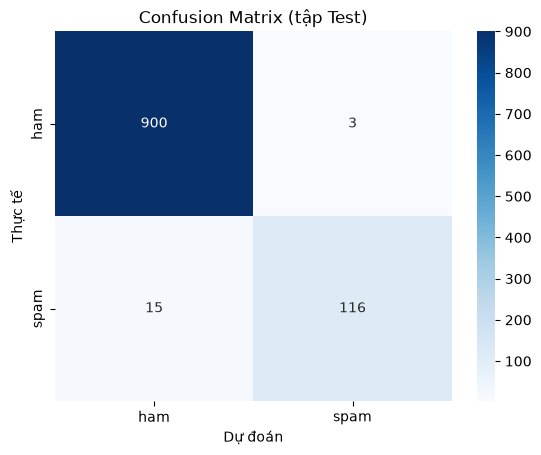

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title("Confusion Matrix (tập Test)")
plt.show()

In [14]:
import numpy as np

# Lấy tin gốc (chưa tiền xử lý) từ df thông qua index của X_test
test_df = df.loc[X_test.index, ["text", "clean_text", "label_num"]].copy()
test_df["pred"] = y_pred

# Spam lọt qua (thực tế spam, đoán ham)
false_neg = test_df[(test_df["label_num"] == 1) & (test_df["pred"] == 0)]
# Ham bị chặn nhầm (thực tế ham, đoán spam)
false_pos = test_df[(test_df["label_num"] == 0) & (test_df["pred"] == 1)]

pd.set_option("display.max_colwidth", 200)
print("=== 3 HAM BỊ ĐOÁN NHẦM THÀNH SPAM ===")
display(false_pos[["text"]])
print("=== 15 SPAM BỊ LỌT QUA ===")
display(false_neg[["text"]])

=== 3 HAM BỊ ĐOÁN NHẦM THÀNH SPAM ===


,text
5157,K k:) sms chat with me.
4860,Nokia phone is lovly..
669,Did u receive my msg?


=== 15 SPAM BỊ LỌT QUA ===


,text
1506,Thanks for the Vote. Now sing along with the stars with Karaoke on your mobile. For a FREE link just reply with SING now.
3062,"Hi babe its Jordan, how r u? Im home from abroad and lonely, text me back if u wanna chat xxSP visionsms.com Text stop to stopCost 150p 08712400603"
5540,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT. BAILIFF DUE IN DAYS. I O å£250 3 WANT å£800
4211,Missed call alert. These numbers called but left no message. 07008009200
671,SMS. ac sun0819 posts HELLO:\You seem cool
1894,"FreeMsg Hey U, i just got 1 of these video/pic fones, reply WILD to this txt & ill send U my pics, hurry up Im so bored at work xxx (18 150p/rcvd STOP2stop)"
2401,Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about we go slo n hard! Txt XXX SLO(4msgs)
4819,Check Out Choose Your Babe Videos @ sms.shsex.netUN fgkslpoPW fgkslpo
2268,88066 FROM 88066 LOST 3POUND HELP
4142,"In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day, B-Blue Day, C-Red Day. (Send A, B or C)"


In [15]:
import importlib, preprocessing
importlib.reload(preprocessing)
from preprocessing import preprocess

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score, StratifiedKFold

df["clean_v2"] = df["text"].apply(lambda t: preprocess(t, tag_numbers=True))
X_train_v2 = df.loc[X_train.index, "clean_v2"]

def cv_f1(X, y):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
        ("nb", MultinomialNB(alpha=0.05)),
    ])
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(pipe, X, y, cv=skf, scoring="f1").mean()

print("v1 (xóa số):     ", cv_f1(X_train, y_train))
print("v2 (gắn token số):", cv_f1(X_train_v2, y_train))

[nltk_data] Downloading package stopwords to C:\Users\NGUYEN
[nltk_data]     CONG\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\NGUYEN
[nltk_data]     CONG\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\NGUYEN
[nltk_data]     CONG\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


v1 (xóa số):      0.9251153434664612
v2 (gắn token số): 0.93652683968589


In [16]:
X_test_v2 = df.loc[X_test.index, "clean_v2"]
joblib.dump((X_train_v2, X_test_v2, y_train, y_test), "../data/train_test_split_v2.pkl")

['../data/train_test_split_v2.pkl']

Accuracy: 0.9845261121856866
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       903
        spam       0.97      0.91      0.94       131

    accuracy                           0.98      1034
   macro avg       0.98      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



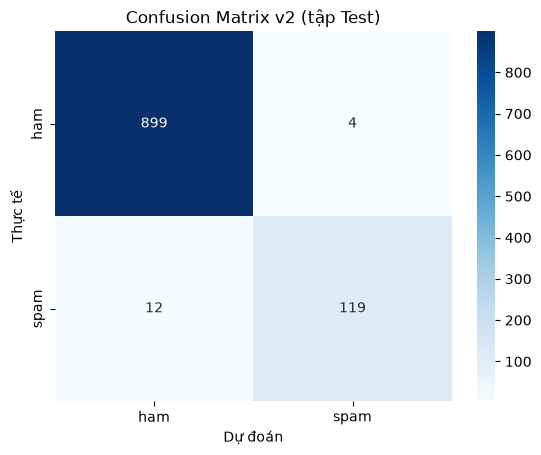

In [17]:
X_train_v2, X_test_v2, y_train, y_test = joblib.load("../data/train_test_split_v2.pkl")
model_v2 = joblib.load("../data/best_sklearn_model_v2.pkl")

y_pred_v2 = model_v2.predict(X_test_v2)

print("Accuracy:", accuracy_score(y_test, y_pred_v2))
print(classification_report(y_test, y_pred_v2, target_names=["ham", "spam"]))

cm_v2 = confusion_matrix(y_test, y_pred_v2)
sns.heatmap(cm_v2, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title("Confusion Matrix v2 (tập Test)")
plt.show()

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for name, pred in [("v1 (xóa số)", y_pred), ("v2 (gắn token số)", y_pred_v2)]:
    rows.append({
        "Phiên bản": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (spam)": precision_score(y_test, pred),
        "Recall (spam)": recall_score(y_test, pred),
        "F1 (spam)": f1_score(y_test, pred),
        "Spam lọt": int(((y_test == 1) & (pred == 0)).sum()),
        "Ham bị chặn nhầm": int(((y_test == 0) & (pred == 1)).sum()),
    })
pd.DataFrame(rows).round(4)

,Phiên bản,Accuracy,Precision (spam),Recall (spam),F1 (spam),Spam lọt,Ham bị chặn nhầm
0,v1 (xóa số),0.9826,0.9748,0.8855,0.928,15,3
1,v2 (gắn token số),0.9845,0.9675,0.9084,0.937,12,4


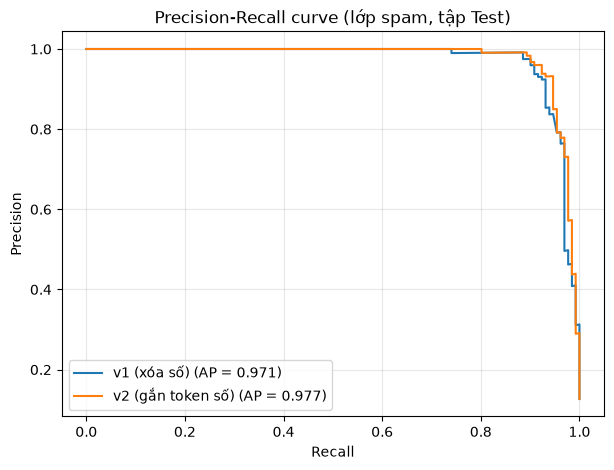

In [19]:
from sklearn.metrics import precision_recall_curve, average_precision_score

proba_v1 = model.predict_proba(X_test)[:, 1]        # xác suất spam của model v1
proba_v2 = model_v2.predict_proba(X_test_v2)[:, 1]  # xác suất spam của model v2

plt.figure(figsize=(7, 5))
for name, proba in [("v1 (xóa số)", proba_v1), ("v2 (gắn token số)", proba_v2)]:
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(r, p, label=f"{name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve (lớp spam, tập Test)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict, StratifiedKFold
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba = cross_val_predict(
    clone(model_v2), X_train_v2, y_train,
    cv=skf, method="predict_proba"
)[:, 1]   # xác suất là spam

In [21]:
y_tr = np.asarray(y_train)
n_ham, n_spam = (y_tr == 0).sum(), (y_tr == 1).sum()

rows = []
for t in [0.5, 0.7, 0.9, 0.95, 0.99, 0.999]:
    pred = (oof_proba >= t).astype(int)
    rows.append({
        "Ngưỡng": t,
        "Ham bị chặn nhầm": int(((y_tr == 0) & (pred == 1)).sum()),
        "Spam lọt": int(((y_tr == 1) & (pred == 0)).sum()),
        "Recall (spam)": round(((y_tr == 1) & (pred == 1)).sum() / n_spam, 4),
    })
display(pd.DataFrame(rows))

# Xác suất spam cao nhất mà một tin ham nhận được
print("Xác suất spam cao nhất của tin HAM:", oof_proba[y_tr == 0].max())

,Ngưỡng,Ham bị chặn nhầm,Spam lọt,Recall (spam)
0,0.500,15,49,0.9061
1,0.700,6,59,0.8870
2,0.900,1,78,0.8506
3,0.950,1,96,0.8161
4,0.990,0,133,0.7452
5,0.999,0,188,0.6398


Xác suất spam cao nhất của tin HAM: 0.9717422184530524


In [22]:
ham_idx = np.where(y_tr == 0)[0]
top = ham_idx[np.argsort(oof_proba[ham_idx])[::-1][:10]]

check = df.loc[X_train_v2.index[top], ["text"]].copy()
check["xác suất spam"] = oof_proba[top].round(4)
pd.set_option("display.max_colwidth", 150)
display(check)

,text,xác suất spam
4847,S.this will increase the chance of winning.,0.9717
4676,Wewa is 130. Iriver 255. All 128 mb.,0.8471
4700,I liked the new mobile,0.8455
1611,645,0.8111
1234,"\Hello-/@drivby-:0quit edrunk sorry iff pthis makes no senrd-dnot no how ^ dancce 2 drum n basq!ihave fun 2nhite x ros xxxxxxx\""""",0.7679
990,26th OF JULY,0.7567
3888,Unlimited texts. Limited minutes.,0.6630
693,Will purchase d stuff today and mail to you. Do you have a po box number?,0.6549
2967,"Mostly sports type..lyk footbl,crckt..",0.6419
3289,My tuition is at 330. Hm we go for the 1120 to 1205 one? Do you mind?,0.6305


Accuracy: 0.9806576402321083
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.99      0.85      0.92       131

    accuracy                           0.98      1034
   macro avg       0.99      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



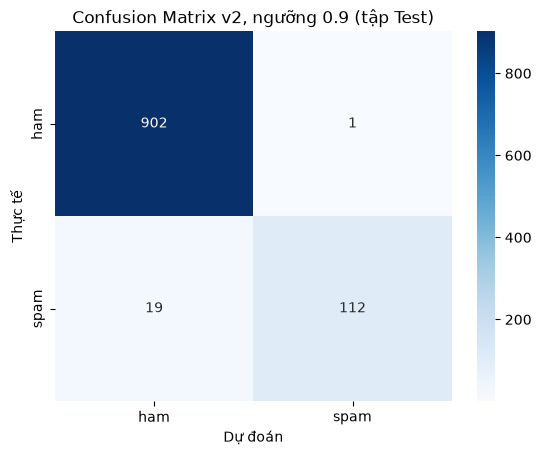

,Cấu hình,Precision (spam),Recall (spam),F1 (spam),Spam lọt,Ham bị chặn nhầm
0,"v1, ngưỡng 0.5",0.9748,0.8855,0.928,15,3
1,"v2, ngưỡng 0.5",0.9675,0.9084,0.937,12,4
2,"v2, ngưỡng 0.9",0.9912,0.8550,0.918,19,1


In [23]:
THRESHOLD = 0.9

# proba_v2 đã tính ở Bước 11; nếu kernel bị khởi động lại thì tính lại dòng dưới
# proba_v2 = model_v2.predict_proba(X_test_v2)[:, 1]

y_pred_v2_t = (proba_v2 >= THRESHOLD).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_v2_t))
print(classification_report(y_test, y_pred_v2_t, target_names=["ham", "spam"]))

cm_t = confusion_matrix(y_test, y_pred_v2_t)
sns.heatmap(cm_t, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title(f"Confusion Matrix v2, ngưỡng {THRESHOLD} (tập Test)")
plt.show()

# Bảng so sánh 3 cấu hình
rows = []
for name, pred in [("v1, ngưỡng 0.5", y_pred),
                   ("v2, ngưỡng 0.5", y_pred_v2),
                   (f"v2, ngưỡng {THRESHOLD}", y_pred_v2_t)]:
    rows.append({
        "Cấu hình": name,
        "Precision (spam)": precision_score(y_test, pred),
        "Recall (spam)": recall_score(y_test, pred),
        "F1 (spam)": f1_score(y_test, pred),
        "Spam lọt": int(((y_test == 1) & (pred == 0)).sum()),
        "Ham bị chặn nhầm": int(((y_test == 0) & (pred == 1)).sum()),
    })
pd.DataFrame(rows).round(4)

In [24]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

cv = CountVectorizer(ngram_range=(1, 2))
Xtr_counts = cv.fit_transform(X_train_v2)   # chỉ fit trên Train
Xte_counts = cv.transform(X_test_v2)

print("Kích thước ma trận Train:", Xtr_counts.shape)
print("Số từ vựng:", len(cv.vocabulary_))

# Mô hình đối chứng của sklearn (cùng đặc trưng, cùng alpha)
ref_nb = MultinomialNB(alpha=0.05).fit(Xtr_counts, y_train)
ref_pred = ref_nb.predict(Xte_counts)
print("F1 (spam) của sklearn trên đặc trưng đếm:", f1_score(y_test, ref_pred))

Kích thước ma trận Train: (4135, 30660)
Số từ vựng: 30660
F1 (spam) của sklearn trên đặc trưng đếm: 0.9389312977099237


In [25]:
import importlib, naive_bayes_scratch
importlib.reload(naive_bayes_scratch)
from naive_bayes_scratch import NaiveBayesScratch

nb = NaiveBayesScratch(alpha=0.05).fit(Xtr_counts, y_train)

print("class_log_prior khớp:  ", np.allclose(nb.class_log_prior_, ref_nb.class_log_prior_))
print("feature_log_prob khớp: ", np.allclose(nb.feature_log_prob_, ref_nb.feature_log_prob_))
print("predict_proba khớp:    ", np.allclose(nb.predict_proba(Xte_counts), ref_nb.predict_proba(Xte_counts)))
print("predict giống hệt:     ", (nb.predict(Xte_counts) == ref_nb.predict(Xte_counts)).all())
print("F1 (spam) bản tự code: ", f1_score(y_test, nb.predict(Xte_counts)))

class_log_prior khớp:   True
feature_log_prob khớp:  True
predict_proba khớp:     True
predict giống hệt:      True
F1 (spam) bản tự code:  0.9389312977099237


In [26]:
tfidf = model_v2.named_steps["tfidf"]          # vectorizer đã fit trên Train
Xtr_tfidf = tfidf.transform(X_train_v2)
Xte_tfidf = tfidf.transform(X_test_v2)

nb_tfidf = NaiveBayesScratch(alpha=0.05).fit(Xtr_tfidf, y_train)
proba_scratch = nb_tfidf.predict_proba(Xte_tfidf)[:, 1]

print("Xác suất khớp model_v2:", np.allclose(proba_scratch, proba_v2))

pred_scratch = (proba_scratch >= 0.9).astype(int)
print("Dự đoán ngưỡng 0.9 giống hệt bản sklearn:", (pred_scratch == y_pred_v2_t).all())
print("Ham chặn nhầm:", int(((y_test == 0) & (pred_scratch == 1)).sum()),
      "| Spam lọt:", int(((y_test == 1) & (pred_scratch == 0)).sum()))

Xác suất khớp model_v2: True
Dự đoán ngưỡng 0.9 giống hệt bản sklearn: True
Ham chặn nhầm: 1 | Spam lọt: 19


In [27]:
import time

def timeit(fn, n=5):
    times = []
    for _ in range(n):
        s = time.perf_counter()
        fn()
        times.append(time.perf_counter() - s)
    return np.median(times)

print("Fit     - tự code:", timeit(lambda: NaiveBayesScratch(alpha=0.05).fit(Xtr_counts, y_train)))
print("Fit     - sklearn:", timeit(lambda: MultinomialNB(alpha=0.05).fit(Xtr_counts, y_train)))
print("Predict - tự code:", timeit(lambda: nb.predict(Xte_counts)))
print("Predict - sklearn:", timeit(lambda: ref_nb.predict(Xte_counts)))

Fit     - tự code: 0.0024794000200927258
Fit     - sklearn: 0.0022690000478178263
Predict - tự code: 0.00019589997828006744
Predict - sklearn: 0.0003130000550299883


In [28]:
lengths = np.asarray(Xte_counts.sum(axis=1)).ravel()
i = lengths.argmax()
row = Xte_counts[i].tocoo()
idx, cnt = row.col, row.data
print("Số đặc trưng trong tin dài nhất:", int(lengths[i]))

for m in [1, 10, 50]:
    for k, c in enumerate(nb.classes_):
        logp = nb.feature_log_prob_[k][idx]
        direct = np.exp(nb.class_log_prior_[k]) * np.prod(np.exp(logp) ** (cnt * m))
        log_score = nb.class_log_prior_[k] + (cnt * m * logp).sum()
        print(f"lặp x{m:<2} | lớp {c}: nhân trực tiếp = {direct:.3e} | log-score = {log_score:.1f}")

Số đặc trưng trong tin dài nhất: 88
lặp x1  | lớp 0: nhân trực tiếp = 2.466e-315 | log-score = -724.4
lặp x1  | lớp 1: nhân trực tiếp = 0.000e+00 | log-score = -937.6
lặp x10 | lớp 0: nhân trực tiếp = 0.000e+00 | log-score = -7242.9
lặp x10 | lớp 1: nhân trực tiếp = 0.000e+00 | log-score = -9357.2
lặp x50 | lớp 0: nhân trực tiếp = 0.000e+00 | log-score = -36214.0
lặp x50 | lớp 1: nhân trực tiếp = 0.000e+00 | log-score = -46777.5


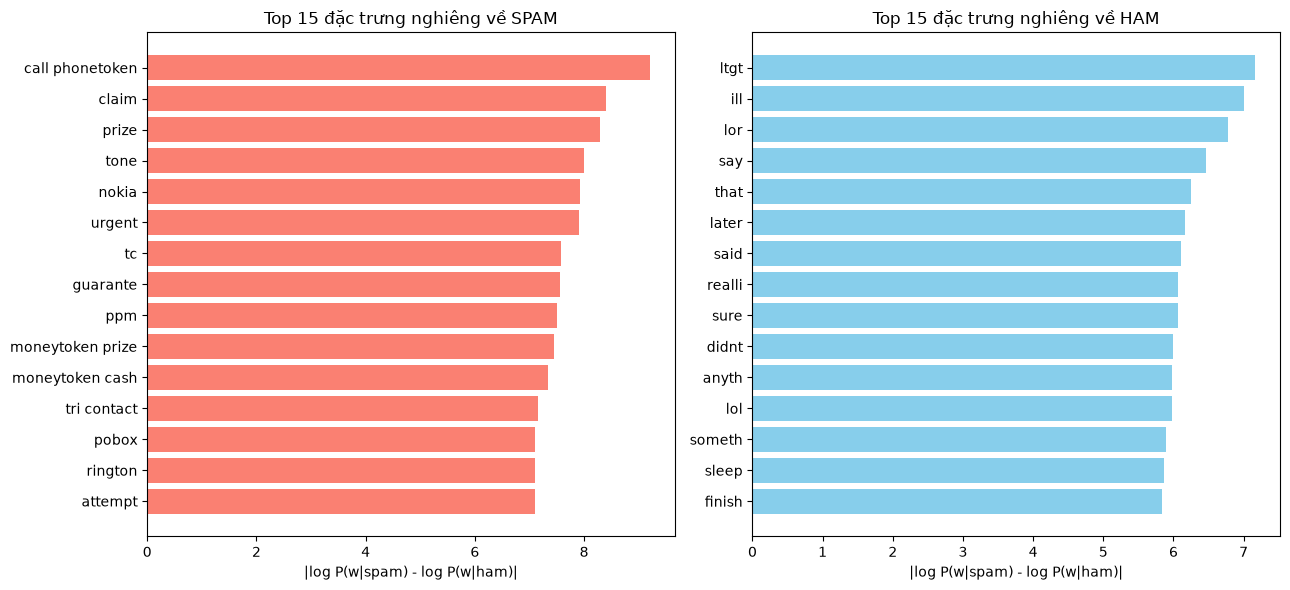

,đặc trưng,log-ratio,số lần trong Train
0,call phonetoken,9.20,162
1,claim,8.40,73
2,prize,8.30,66
3,tone,8.00,49
4,nokia,7.92,45
5,urgent,7.90,44
6,tc,7.58,32
7,guarante,7.55,31
8,ppm,7.51,30
9,moneytoken prize,7.44,28


,đặc trưng,log-ratio,số lần trong Train
0,ltgt,-7.16,196
1,ill,-7.00,167
2,lor,-6.77,133
3,say,-6.47,98
4,that,-6.25,79
5,later,-6.16,72
6,said,-6.10,68
7,realli,-6.07,66
8,sure,-6.06,65
9,didnt,-5.99,61


In [29]:
feature_names = np.array(cv.get_feature_names_out())
log_ratio = nb.feature_log_prob_[1] - nb.feature_log_prob_[0]   # > 0: nghiêng về spam
total_counts = np.asarray(Xtr_counts.sum(axis=0)).ravel()
valid = np.where(total_counts >= 5)[0]      # bỏ đặc trưng quá hiếm

def top_features(direction, k=15):
    order = valid[np.argsort(direction * log_ratio[valid])[::-1][:k]]
    return pd.DataFrame({"đặc trưng": feature_names[order],
                         "log-ratio": log_ratio[order].round(2),
                         "số lần trong Train": total_counts[order]})

spam_top, ham_top = top_features(+1), top_features(-1)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh(spam_top["đặc trưng"][::-1], spam_top["log-ratio"][::-1], color="salmon")
axes[0].set_title("Top 15 đặc trưng nghiêng về SPAM")
axes[1].barh(ham_top["đặc trưng"][::-1], -ham_top["log-ratio"][::-1], color="skyblue")
axes[1].set_title("Top 15 đặc trưng nghiêng về HAM")
for ax in axes:
    ax.set_xlabel("|log P(w|spam) - log P(w|ham)|")
plt.tight_layout()
plt.show()

display(spam_top)
display(ham_top)

In [30]:
# 1) "&lt;#&gt;" xuất hiện ở nhãn nào?
mask = df["text"].str.contains("&lt;#&gt;", regex=False)
print("Số tin chứa &lt;#&gt;:", mask.sum())
print(df[mask]["label"].value_counts())

# 2) Dạng rút gọn (contraction) đi qua tiền xử lý ra sao?
print(preprocess("that's fine, I'll call you later, didn't say", tag_numbers=True))

Số tin chứa &lt;#&gt;: 197
label
ham    197
Name: count, dtype: int64
that fine ill call later didnt say


In [31]:
tfidf = model_v2.named_steps["tfidf"]
nb_tfidf = NaiveBayesScratch(alpha=0.05).fit(tfidf.transform(X_train_v2), y_train)
joblib.dump(nb_tfidf, "../data/nb_scratch_tfidf.pkl")

['../data/nb_scratch_tfidf.pkl']